## Read docx

In [1]:
from docx import Document
from pathlib import Path

file_path=r"C:\Users\Admin\Downloads\BÁO CÁO ĐỀ XUẤT Ý TƯỞNG SẢN PHẨM.docx"
path=Path(file_path)
print(f"Kieu tai lieu: {path.suffix.lower()}")
document=Document(path)

# Đọc text
text=[]
for paragraph in document.paragraphs:
    text.append(paragraph.text)
    break
docs="\n".join(text)
print(f"Dong dau tien: {docs}")

# Đọc bảng
lines=[]
print(f"Số bảng trong document: {len(document.tables)}")
for table in document.tables:
    print("\n----------- Show mẫu 1 bảng -----------")
    for row in table.rows:
        lines.append(" | ".join(cell.text.strip() for cell in row.cells))
    break
res = "\n".join(line for line in lines if line)
print(res)

Kieu tai lieu: .docx
Dong dau tien: Thuyết trình
Số bảng trong document: 11

----------- Show mẫu 1 bảng -----------
STT | Mục chính | Mục đích & Nội dung cần thể hiện | 
1 | Problem | Bài toán thực tế cần giải quyết | Ngân
2 | Target Customers | Ai là người dùng / khách hàng mục tiêu? | Ngân
3 | Solution | Giải pháp mà dự án mang lại | Ngân
4 | Innovation | Điểm mới, sự khác biệt so với thị trường | Ngân
5 | Technology | Công nghệ cốt lõi được ứng dụng | Tú
6 | Business Model | Mô hình kinh doanh, cách tạo doanh thu | Ngân
7 | Traction / Validation | Minh chứng về tính khả thi của dự án | 
8 | Team & Demo | Năng lực triển khai của đội ngũ | Ngân


## Read pdf

In [2]:
pip install pypdf

Note: you may need to restart the kernel to use updated packages.


In [3]:
from pypdf import PdfReader
from pathlib import Path

file_path=r"C:\Users\Admin\Downloads\state2_R2AI.pdf"
path=Path(file_path)

reader=PdfReader(path)
documents=[]
for page in reader.pages:
    documents.append(page.extract_text())

docs="\n".join(documents)

## md, txt

In [4]:
path=r"C:\Users\Admin\Downloads\hi.txt"
path=Path(path)
docs=path.read_text()
print(docs)
print(path.read_bytes())

Xin chào, đang test read_docx từ Path

b'Xin ch\xc3\xa0o, \xc4\x91ang test read_docx t\xe1\xbb\xab Path\r\n'


## STT

In [5]:
import os
import json
from groq import Groq

client = Groq()

filename = r"C:\Users\Admin\Downloads\test-prj.mp3"

with open(filename, "rb") as file:
    transcription = client.audio.transcriptions.create(
      file=file, 
      model="whisper-large-v3-turbo",
      prompt="Specify context or spelling",  
      response_format="verbose_json", 
      timestamp_granularities = ["word", "segment"], 
      language="vi",  
      temperature=0.0  
    )
    trans_dict = transcription.model_dump() if hasattr(transcription, 'model_dump') else (transcription.dict() if hasattr(transcription, 'dict') else vars(transcription))
    print(json.dumps(trans_dict, indent=2, ensure_ascii=False, default=str))


{
  "text": " Nếu bạn chiêu ánh sáng màu xanh lá, đỏ và xanh dương, mỗi màu sẽ kích thích một tập hợp tế bào nón khác nhau ở phía sau mắt bạn. Và khi cả 3 tế bào này được kích hoạt cùng một lúc, não bạn sẽ bị đánh lừa nhìn thấy ánh sáng trắng ở nơi các trùm sáng đè lên nhau. Bây giờ, nếu bạn đặt một tấm bảng có khay hẹp phía trước bức tường, nó sẽ tách ánh sáng trắng trở lại thành 3 giải màu, vì mỗi ánh sáng đến từ một vị trí hơi khác nhau. Nhưng nếu có thứ gì đó cản một phần ánh sáng, nó sẽ tạo ra 3 cái bóng có màu Bởi vì từ mỗi góc độ, một màu bị cản lại trong khi hai màu còn lại tiếp tục hòa trộn với nhau Cản màu xanh dương, đỏ kết hợp với xanh lá tạo ra màu vàng Cản màu xanh lá, đỏ kết hợp với xanh dương tạo ra màu hồng cánh sen Cản màu đỏ, xanh lá kết hợp với xanh dương tạo ra màu xanh lơ I've got three flashlights here, a blue one, a green one, and a red one. And as you can see when their beams all combine, you get white light. And if you take a piece of paper with a slit in it, 

In [6]:
raw_segments = trans_dict.get("segments", []) 
print(raw_segments)

[{'id': 0, 'seek': 0, 'start': 0, 'end': 5.72, 'text': ' Nếu bạn chiêu ánh sáng màu xanh lá, đỏ và xanh dương, mỗi màu sẽ kích thích một tập hợp tế bào nón khác nhau ở phía sau mắt bạn.', 'tokens': [50365, 426, 30568, 14647, 13228, 28310, 7352, 5728, 262, 30344, 13901, 84, 2031, 50214, 7453, 11, 2934, 21920, 10274, 2031, 50214, 274, 24605, 11, 275, 49572, 13901, 84, 17208, 350, 30839, 258, 30839, 15486, 256, 35148, 276, 27836, 79, 256, 6115, 272, 20807, 297, 1801, 43713, 6245, 1459, 19272, 903, 2686, 17828, 275, 31454, 14647, 13, 50651], 'temperature': 0, 'avg_logprob': -0.044502247, 'compression_ratio': 1.7246376, 'no_speech_prob': 0}, {'id': 1, 'seek': 0, 'start': 6.14, 'end': 11.84, 'text': ' Và khi cả 3 tế bào này được kích hoạt cùng một lúc, não bạn sẽ bị đánh lừa nhìn thấy ánh sáng trắng ở nơi các trùm sáng đè lên nhau.', 'tokens': [50672, 44851, 23526, 22227, 805, 256, 6115, 272, 20807, 12542, 15832, 350, 30839, 1106, 44664, 45701, 15486, 287, 31585, 11, 2431, 14647, 17208, 3211

In [7]:
 for index, segment in enumerate(raw_segments, start=1):
    data = segment if isinstance(segment, dict) else (segment.model_dump() if hasattr(segment, "model_dump") else vars(segment))
    print(data)

{'id': 0, 'seek': 0, 'start': 0, 'end': 5.72, 'text': ' Nếu bạn chiêu ánh sáng màu xanh lá, đỏ và xanh dương, mỗi màu sẽ kích thích một tập hợp tế bào nón khác nhau ở phía sau mắt bạn.', 'tokens': [50365, 426, 30568, 14647, 13228, 28310, 7352, 5728, 262, 30344, 13901, 84, 2031, 50214, 7453, 11, 2934, 21920, 10274, 2031, 50214, 274, 24605, 11, 275, 49572, 13901, 84, 17208, 350, 30839, 258, 30839, 15486, 256, 35148, 276, 27836, 79, 256, 6115, 272, 20807, 297, 1801, 43713, 6245, 1459, 19272, 903, 2686, 17828, 275, 31454, 14647, 13, 50651], 'temperature': 0, 'avg_logprob': -0.044502247, 'compression_ratio': 1.7246376, 'no_speech_prob': 0}
{'id': 1, 'seek': 0, 'start': 6.14, 'end': 11.84, 'text': ' Và khi cả 3 tế bào này được kích hoạt cùng một lúc, não bạn sẽ bị đánh lừa nhìn thấy ánh sáng trắng ở nơi các trùm sáng đè lên nhau.', 'tokens': [50672, 44851, 23526, 22227, 805, 256, 6115, 272, 20807, 12542, 15832, 350, 30839, 1106, 44664, 45701, 15486, 287, 31585, 11, 2431, 14647, 17208, 32113,

## PaddleOCR

In [ ]:
from paddleocr import PPStructureV3

image_path=r"C:\Users\Admin\Downloads\ocr_demo.png"
output_dir="output_structure"

pipeline = PPStructureV3(
    use_doc_orientation_classify=True,
    use_doc_unwarping=True,
)

results = pipeline.predict(input=image_path)

for result in results:
    result.print()
    result.save_to_json(save_path=output_dir)
    result.save_to_markdown( save_path=output_dir)



Creating model: ('PP-OCRv6_medium_det', None, 'transformers')
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Admin\.paddlex\official_models\PP-OCRv6_medium_det_safetensors`.
Loading weights: 100%|██████████| 350/350 [00:00<00:00, 7675.93it/s]
Creating model: ('PP-OCRv6_medium_rec', None, 'transformers')
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Admin\.paddlex\official_models\PP-OCRv6_medium_rec_safetensors`.
Loading weights: 100%|██████████| 269/269 [00:00<00:00, 7384.48it/s]


{'output_img': array([[[254, ..., 254],
        ...,
        [254, ..., 254]],

       ...,

       [[254, ..., 254],
        ...,
        [254, ..., 254]]], shape=(594, 697, 3), dtype=uint8)}
<class 'list'>
1
['input_path', 'page_index', 'doc_preprocessor_res', 'dt_polys', 'model_settings', 'text_det_params', 'text_type', 'text_rec_score_thresh', 'return_word_box', 'rec_texts', 'rec_scores', 'rec_polys', 'vis_fonts', 'textline_orientation_angles', 'rec_boxes']
Content: ['Don', 'Só', 'STT', 'Tên săn phm, Linh kin', 'vi'] ---- Confident: [0.9421305060386658, 0.7775092124938965, 0.9999618530273438, 0.9872578382492065, 0.7785576581954956]
Boxes: [[309 ...  40]
 ...
 [505 ... 582]] 
Shape of Boxes: (80, 4) 


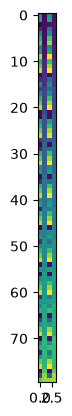

In [20]:
from paddleocr import PaddleOCR
import matplotlib.pyplot as plt 

ocr = PaddleOCR(
    text_detection_model_name="PP-OCRv6_medium_det",
    text_recognition_model_name="PP-OCRv6_medium_rec",
    engine="transformers",
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
)
result = ocr.predict(image_path)
print(res['doc_preprocessor_res'])
print(type(result))
print(len(result))
for res in result:
    keys=list(res.keys())
    print(keys)
    print(f"Content: {res.get("rec_texts")[:5]} ---- Confident: {res.get("rec_scores")[:5]}")
    print(f"Boxes: {res.get("rec_boxes")} ")
    print(f"Shape of Boxes: {res.get("rec_boxes").shape} ")
    res.save_to_img("output_vis.png")
    plt.imshow(res.get("rec_boxes"))
    plt.show()


# Aligner

In [2]:
from sentence_transformers import CrossEncoder
from app.schemas.evidence import EvidenceRef
from app.core.constants import SourceType

model = CrossEncoder("BAAI/bge-reranker-v2-m3")

def align_sources_cross_encoder(
    evidence: list[EvidenceRef],
    threshold: float = 0.7,
) -> list[dict]:
    groups: list[dict] = []

    for item in evidence:
        best_group = None
        best_score = -1.0

        if groups:

            pairs = [(item.content, g["representative_text"]) for g in groups]
            scores = model.predict(pairs)

            for group, score in zip(groups, scores):
                if score > best_score:
                    best_score = float(score)
                    best_group = group

        if best_group and best_score >= threshold:
            best_group["evidence_ids"].append(item.evidence_id)
        else:
            groups.append({
                "group_id": f"GROUP_{len(groups) + 1:03d}",
                "representative_text": item.content,
                "evidence_ids": [item.evidence_id],
            })

    return groups

ModuleNotFoundError: No module named 'app'

In [ ]:
if __name__ == "__main__":
    sample_evidence = [
        EvidenceRef(
            evidence_id="AUDIO_01",
            source_type=SourceType.AUDIO,
            source_id="meeting.mp3",
            content="Minh bảo chốt gửi báo giá trước thứ 6 tuần này nha.",
        ),
        EvidenceRef(
            evidence_id="OCR_01",
            source_type=SourceType.IMAGE,
            source_id="invoice.jpg",
            content="Hạn chót bản chào giá: Thứ Sáu - Anh Minh phụ trách",
        ),
        EvidenceRef(
            evidence_id="TEXT_01",
            source_type=SourceType.MEETING_SCRIPT,
            source_id="notes.txt",  
            content="Đặt lịch họp phòng 302 vào lúc 9h sáng thứ Hai.",
        ),
        EvidenceRef(
            evidence_id="AUDIO_02",
            source_type=SourceType.AUDIO,
            source_id="call.mp3",
            content="Sáng T2 tuần sau 9 giờ họp ở phòng ba trăm lẻ hai.",
        ),
    ]

    res=align_sources_cross_encoder(sample_evidence)
    for g in res:
        print(g)

In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    separators=["\n\n", "\n", ". ", " "]  # Ưu tiên ngắt ở xuống dòng trước, sau đó mới đến dấu chấm
)

blocks = text_splitter.split_text(raw_text)


NameError: name 'raw_text' is not defined